In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cargamos la base de datos
df = pd.read_csv("Leads Reales.csv")

# Mostramos las primeras filas
df.head()

,Efectivadad de Leads,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,"30,189","3,851","5,748",510,929,"17,748","6,545",720,4.0%,64.0%,NaN,NaN
1,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,NaN,NaN
2,2024,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
4,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN


In [4]:
# Cargamos la base de datos ignorando las primeras filas que no forman parte de la tabla
df = pd.read_csv("Leads Reales.csv", skiprows=2, usecols=range(12))

# Quitamos espacios sobrantes de los nombres de las columnas
df.columns = df.columns.str.strip()

df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%


In [5]:
df.shape

(44, 12)

In [ ]:
# Quitamos espacios sobrantes de la columna Mes
df['Mes'] = df['Mes'].astype('string').str.strip()

# Lista de meses válidos
meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril',
    'Mayo', 'Junio', 'Julio', 'Agosto',
    'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

# Conservamos únicamente las filas correspondientes a meses
df = df[df['Mes'].isin(meses)].copy()

# Reiniciamos los índices
df.reset_index(drop=True, inplace=True)

df

In [6]:
# Quitamos espacios sobrantes de la columna Mes
df['Mes'] = df['Mes'].astype('string').str.strip()

# Lista de meses válidos
meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril',
    'Mayo', 'Junio', 'Julio', 'Agosto',
    'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

# Conservamos únicamente las filas correspondientes a meses
df = df[df['Mes'].isin(meses)].copy()

# Reiniciamos los índices
df.reset_index(drop=True, inplace=True)

df

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%
5,NaN,Junio,967,140,173,31,3,620,17,6,1.0%,64%
6,NaN,Julio,954,112,251,12,9,570,5,21,3.7%,60%
7,NaN,Agosto,"1,409",504,324,17,18,546,22,17,3.1%,39%
8,NaN,Septiembre,"1,315",431,314,14,26,530,42,17,3.2%,40%
9,NaN,Octubre,"1,973",514,606,18,13,822,72,23,2.8%,42%


In [7]:
# Imputamos los valores nulos de Año con el año anterior correspondiente
df['Año'] = df['Año'].ffill()

# Convertimos Año a tipo numérico
df['Año'] = pd.to_numeric(df['Año'], errors='coerce').astype('Int64')

df[['Año', 'Mes']]

,Año,Mes
0,2024,Enero
1,2024,Febrero
2,2024,Marzo
3,2024,Abril
4,2024,Mayo
5,2024,Junio
6,2024,Julio
7,2024,Agosto
8,2024,Septiembre
9,2024,Octubre


In [8]:
# Revisamos los valores nulos existentes en cada columna
df.isnull().sum()

Año                     0
Mes                     0
Total                   1
Ilocalizable            1
No Contesta             1
D. Incorrectos          1
Duplicados              1
Efectivos               1
Abiertos                1
Ventas                  1
Conversion              1
Efectividad de Leads    1
dtype: int64

In [9]:
# Mostramos las filas que contienen valores nulos
df[df.isnull().any(axis=1)]

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Eliminamos las filas que no contienen información de las variables de análisis
df = df.dropna(subset=['Total'])

# Reiniciamos nuevamente el índice
df.reset_index(drop=True, inplace=True)

df

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,Febrero,543,108,33,0,1,389,1,12,3.1%,72%
1,2024,Marzo,178,37,13,0,0,128,1,7,5.5%,72%
2,2024,Abril,416,79,46,3,0,288,1,8,2.8%,69%
3,2024,Mayo,422,33,100,17,0,274,5,13,4.7%,65%
4,2024,Junio,967,140,173,31,3,620,17,6,1.0%,64%
5,2024,Julio,954,112,251,12,9,570,5,21,3.7%,60%
6,2024,Agosto,"1,409",504,324,17,18,546,22,17,3.1%,39%
7,2024,Septiembre,"1,315",431,314,14,26,530,42,17,3.2%,40%
8,2024,Octubre,"1,973",514,606,18,13,822,72,23,2.8%,42%
9,2024,Noviembre,"1,562",153,321,44,4,"1,040",79,22,2.1%,67%


In [11]:
df.isnull().sum()

Año                     0
Mes                     0
Total                   0
Ilocalizable            0
No Contesta             0
D. Incorrectos          0
Duplicados              0
Efectivos               0
Abiertos                0
Ventas                  0
Conversion              0
Efectividad de Leads    0
dtype: int64

In [ ]:
# Creamos un diccionario para convertir los meses a números
meses_numero = {
    'Enero': 1,
    'Febrero': 2,
    'Marzo': 3,
    'Abril': 4,
    'Mayo': 5,
    'Junio': 6,
    'Julio': 7,
    'Agosto': 8,
    'Septiembre': 9,
    'Octubre': 10,
    'Noviembre': 11,
    'Diciembre': 12
}

# Reemplazamos los nombres de los meses por números
df['Mes'] = df['Mes'].map(meses_numero)


,Año,Mes
0,2024,2
1,2024,3
2,2024,4
3,2024,5
4,2024,6


In [14]:
df.head(15)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,2,543,108,33,0,1,389,1,12,3.1%,72%
1,2024,3,178,37,13,0,0,128,1,7,5.5%,72%
2,2024,4,416,79,46,3,0,288,1,8,2.8%,69%
3,2024,5,422,33,100,17,0,274,5,13,4.7%,65%
4,2024,6,967,140,173,31,3,620,17,6,1.0%,64%
5,2024,7,954,112,251,12,9,570,5,21,3.7%,60%
6,2024,8,"1,409",504,324,17,18,546,22,17,3.1%,39%
7,2024,9,"1,315",431,314,14,26,530,42,17,3.2%,40%
8,2024,10,"1,973",514,606,18,13,822,72,23,2.8%,42%
9,2024,11,"1,562",153,321,44,4,"1,040",79,22,2.1%,67%


In [15]:
# Columnas que deben ser numéricas
columnas_numericas = [
    'Total',
    'Ilocalizable',
    'No Contesta',
    'D. Incorrectos',
    'Duplicados',
    'Efectivos',
    'Abiertos',
    'Ventas'
]

# Quitamos comas de miles y convertimos a número
for columna in columnas_numericas:
    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
    )

    df[columna] = pd.to_numeric(df[columna], errors='coerce')

In [16]:
# Convertimos las columnas de porcentaje a tipo numérico

df['Conversion'] = (
    df['Conversion']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
)

df['Conversion'] = pd.to_numeric(df['Conversion'], errors='coerce')


df['Efectividad de Leads'] = (
    df['Efectividad de Leads']
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.strip()
)

df['Efectividad de Leads'] = pd.to_numeric(
    df['Efectividad de Leads'],
    errors='coerce'
)

In [17]:
# Convertimos Año y Mes a tipo numérico entero
df['Año'] = pd.to_numeric(df['Año']).astype(int)
df['Mes'] = pd.to_numeric(df['Mes']).astype(int)

In [18]:
df.dtypes

Año                       int64
Mes                       int64
Total                     int64
Ilocalizable              int64
No Contesta               int64
D. Incorrectos            int64
Duplicados                int64
Efectivos                 int64
Abiertos                  int64
Ventas                    int64
Conversion              float64
Efectividad de Leads      int64
dtype: object

In [20]:
# Estadísticas descriptivas de la base
df.describe()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,2024.785714,6.071429,1122.857143,143.178571,209.428571,19.107143,33.857143,660.142857,250.107143,26.964286,4.142857,61.642857
std,0.738223,3.452627,421.939939,143.704185,153.734844,19.345474,32.244109,211.922018,236.059839,11.083796,1.249720,11.907714
min,2024.000000,1.000000,178.000000,5.000000,13.000000,0.000000,0.000000,128.000000,1.000000,6.000000,1.000000,39.000000
25%,2024.000000,3.000000,946.750000,44.250000,103.000000,3.000000,12.000000,564.000000,37.000000,19.250000,3.275000,52.750000
50%,2025.000000,5.500000,1170.500000,110.000000,185.500000,13.000000,27.000000,704.500000,200.500000,30.000000,4.050000,64.000000
75%,2025.000000,9.000000,1397.000000,154.250000,278.000000,31.750000,53.000000,738.000000,368.000000,36.250000,5.275000,70.000000
max,2026.000000,12.000000,1973.000000,514.000000,606.000000,62.000000,136.000000,1040.000000,823.000000,41.000000,5.900000,83.000000


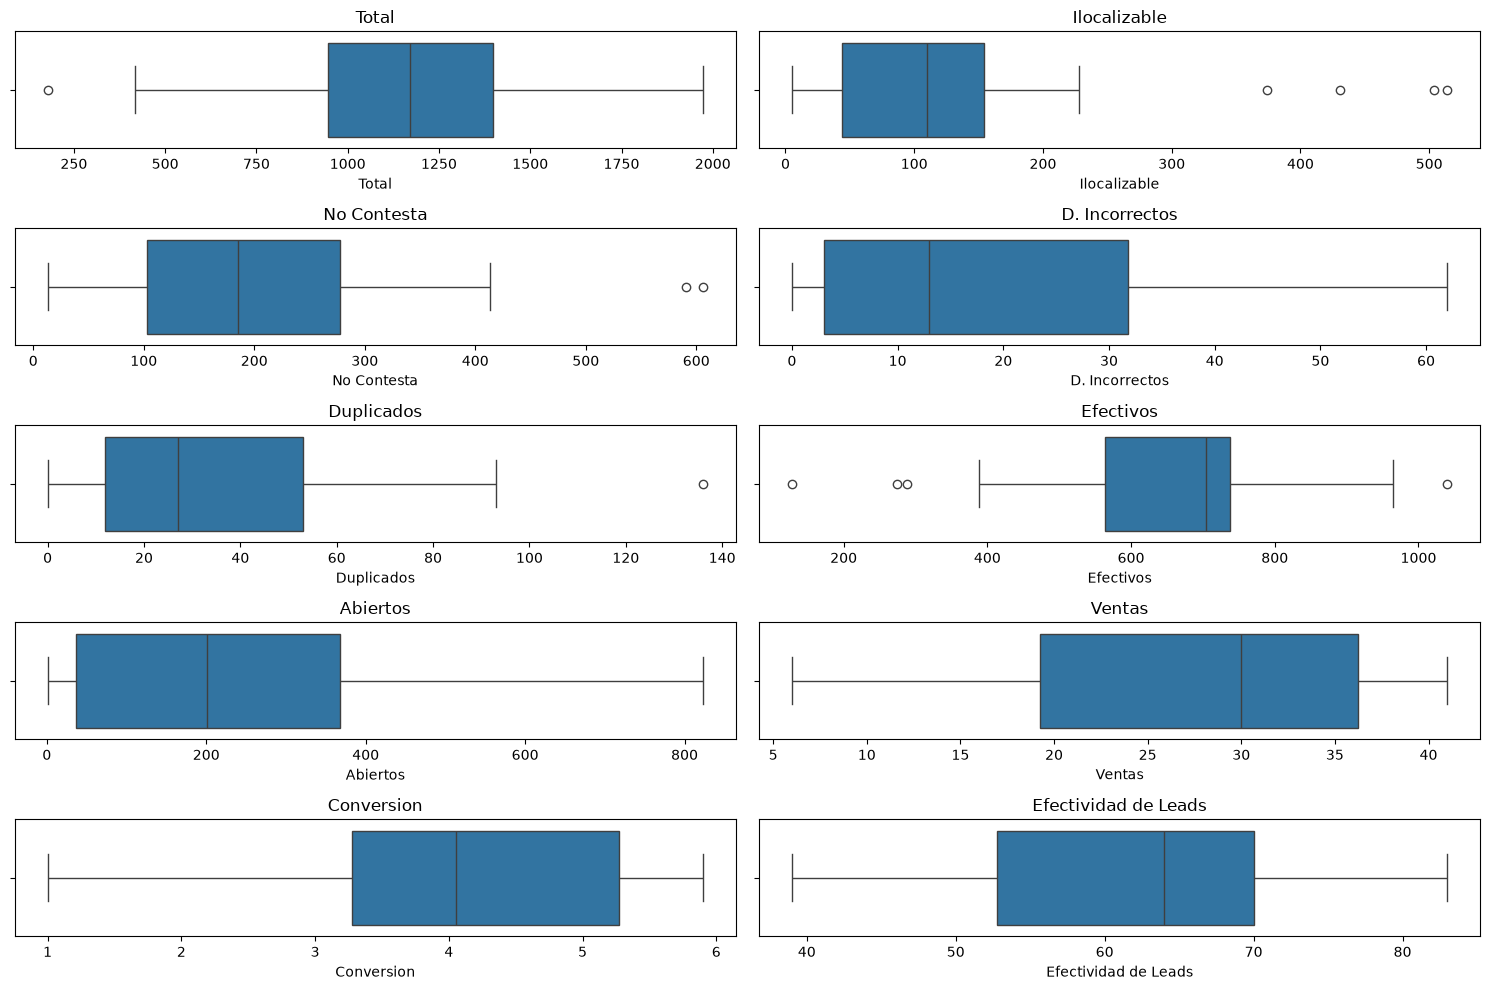

In [21]:
# Variables que vamos a revisar
variables = [
    'Total',
    'Ilocalizable',
    'No Contesta',
    'D. Incorrectos',
    'Duplicados',
    'Efectivos',
    'Abiertos',
    'Ventas',
    'Conversion',
    'Efectividad de Leads'
]

# Creamos boxplots para detectar posibles valores atípicos
plt.figure(figsize=(15, 10))

for i, columna in enumerate(variables, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x=df[columna])
    plt.title(columna)

plt.tight_layout()
plt.show()

In [22]:
# Función para detectar valores atípicos mediante el método IQR

for columna in variables:

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("\nVariable:", columna)
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)

    if len(outliers) > 0:
        print(outliers[['Año', 'Mes', columna]])
    else:
        print("No se encontraron valores atípicos")


Variable: Total
Límite inferior: 271.375
Límite superior: 2072.375
    Año  Mes  Total
1  2024    3    178

Variable: Ilocalizable
Límite inferior: -120.75
Límite superior: 319.25
     Año  Mes  Ilocalizable
6   2024    8           504
7   2024    9           431
8   2024   10           514
10  2024   12           374

Variable: No Contesta
Límite inferior: -159.5
Límite superior: 540.5
     Año  Mes  No Contesta
8   2024   10          606
18  2025    8          591

Variable: D. Incorrectos
Límite inferior: -40.125
Límite superior: 74.875
No se encontraron valores atípicos

Variable: Duplicados
Límite inferior: -49.5
Límite superior: 114.5
     Año  Mes  Duplicados
11  2025    1         136

Variable: Efectivos
Límite inferior: 303.0
Límite superior: 999.0
    Año  Mes  Efectivos
1  2024    3        128
2  2024    4        288
3  2024    5        274
9  2024   11       1040

Variable: Abiertos
Límite inferior: -459.5
Límite superior: 864.5
No se encontraron valores atípicos

Variable

In [24]:
# Guardamos la base limpia
df.to_csv("Leads_Reales_Depurados.csv", index=False)

In [25]:
# Calculamos la matriz de correlación
correlacion = df.corr(numeric_only=True)

correlacion

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
Año,1.000000,-0.371581,0.344364,-0.266705,-0.131004,0.180612,0.372096,0.387510,0.800323,0.745898,0.536228,-0.105934
Mes,-0.371581,1.000000,0.417563,0.393890,0.641403,0.000990,-0.136307,0.355581,0.054022,0.184924,-0.077131,-0.302947
Total,0.344364,0.417563,1.000000,0.588110,0.644815,0.453006,0.260949,0.812001,0.528382,0.534564,-0.133595,-0.653776
Ilocalizable,-0.266705,0.393890,0.588110,1.000000,0.443577,0.293649,-0.162391,0.245740,-0.047827,-0.106959,-0.413785,-0.645820
No Contesta,-0.131004,0.641403,0.644815,0.443577,1.000000,-0.040028,0.012199,0.383725,0.013522,0.219976,-0.088043,-0.611360
D. Incorrectos,0.180612,0.000990,0.453006,0.293649,-0.040028,1.000000,0.287165,0.468292,0.382420,0.143903,-0.247300,-0.177488
Duplicados,0.372096,-0.136307,0.260949,-0.162391,0.012199,0.287165,1.000000,0.467451,0.336402,0.451099,0.085728,0.139829
Efectivos,0.387510,0.355581,0.812001,0.245740,0.383725,0.468292,0.467451,1.000000,0.495192,0.654887,-0.137212,-0.115353
Abiertos,0.800323,0.054022,0.528382,-0.047827,0.013522,0.382420,0.336402,0.495192,1.000000,0.752551,0.445734,-0.281941
Ventas,0.745898,0.184924,0.534564,-0.106959,0.219976,0.143903,0.451099,0.654887,0.752551,1.000000,0.626595,-0.115155


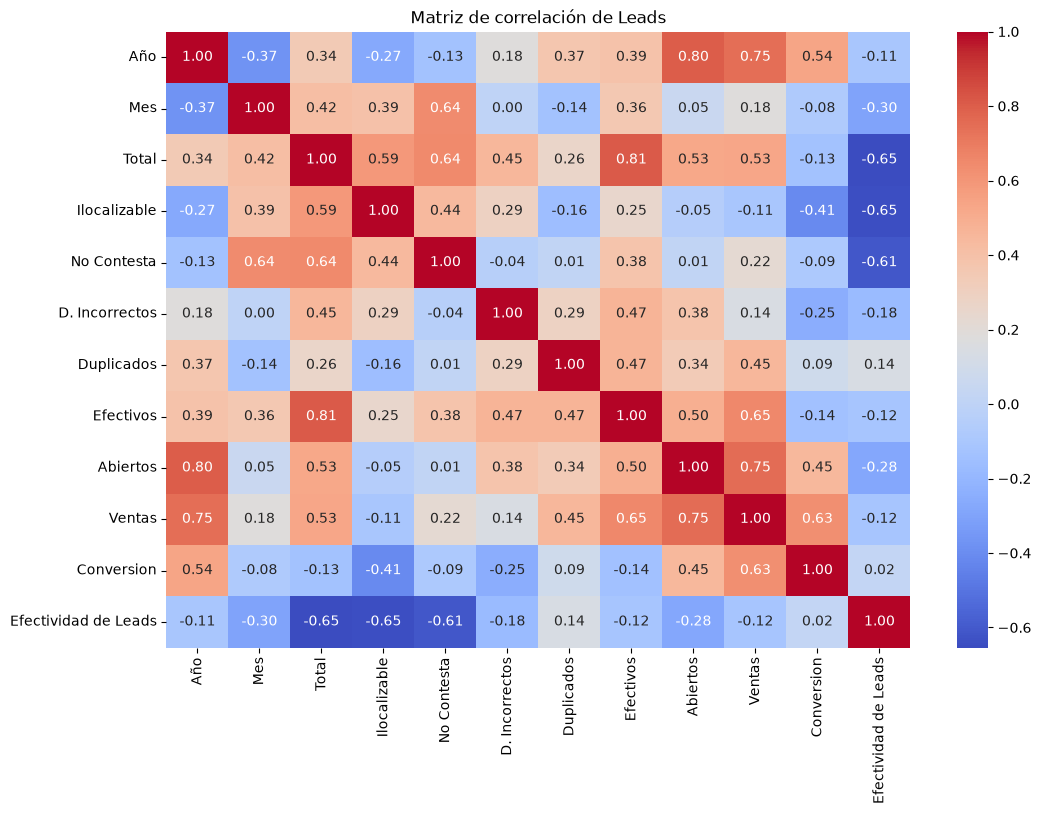

In [26]:
# Mapa de calor de correlaciones

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación de Leads')

plt.show()

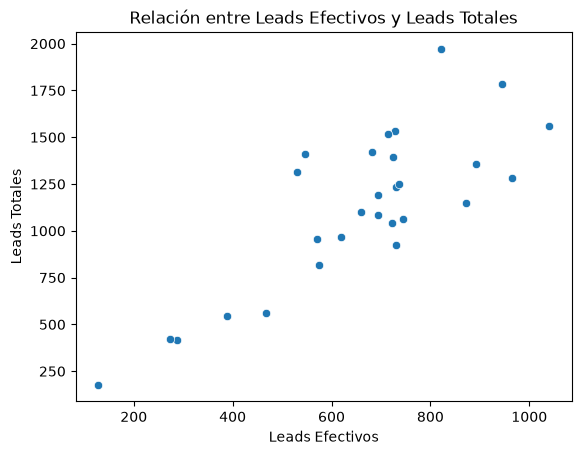

In [27]:
# Gráfica de dispersión entre Efectivos y Total

sns.scatterplot(
    x='Efectivos',
    y='Total',
    data=df
)

plt.title('Relación entre Leads Efectivos y Leads Totales')
plt.xlabel('Leads Efectivos')
plt.ylabel('Leads Totales')

plt.show()

In [28]:
# Declaramos la variable independiente y dependiente

Vars_Indep = df[['Efectivos']]
Var_Dep = df['Total']

In [31]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 15.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 26.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [32]:
from sklearn.linear_model import LinearRegression

# Creamos el modelo de regresión lineal
model = LinearRegression()

In [33]:
# Ajustamos el modelo con las variables seleccionadas

model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.62]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Efectivos']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,55.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [34]:
# Revisamos los coeficientes obtenidos

model.__dict__
# Mostramos pendiente e intercepto

print("Pendiente:", model.coef_[0])
print("Intercepto:", model.intercept_)

Pendiente: 1.6167053950864319
Intercepto: 55.600624186514096


In [35]:
# Evaluamos el modelo mediante el coeficiente de determinación R²

coef_determinacion = model.score(Vars_Indep, Var_Dep)

coef_determinacion

0.6593449223982559

In [36]:
# Generamos los valores predichos de Total
# a partir de los Leads Efectivos

y_pred = model.predict(df[['Efectivos']])

y_pred

array([ 684.49902288,  262.53891476,  521.21177797,  498.57790244,
       1057.95796914,  977.12269939,  938.3217699 ,  912.45448358,
       1384.53245895, 1736.97423508, 1615.72133044, 1224.47862483,
        812.21874909, 1237.41226799, 1465.3677287 ,  983.58952097,
       1177.59416838, 1499.318542  , 1156.57699824, 1122.62618494,
       1179.21087377, 1258.42943813, 1234.1788572 , 1209.92827628,
       1235.7955626 , 1581.77051715, 1226.09533023, 1245.49579497])

In [37]:
# Agregamos las predicciones a la base

df['Total_Predicho'] = y_pred

df[['Año', 'Mes', 'Efectivos', 'Total', 'Total_Predicho']].head(10)

,Año,Mes,Efectivos,Total,Total_Predicho
0,2024,2,389,543,684.499023
1,2024,3,128,178,262.538915
2,2024,4,288,416,521.211778
3,2024,5,274,422,498.577902
4,2024,6,620,967,1057.957969
5,2024,7,570,954,977.122699
6,2024,8,546,1409,938.321770
7,2024,9,530,1315,912.454484
8,2024,10,822,1973,1384.532459
9,2024,11,1040,1562,1736.974235


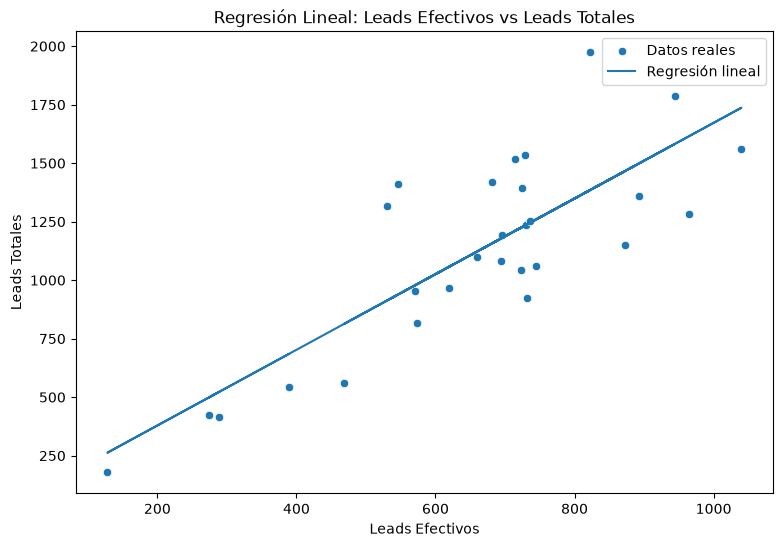

In [38]:
# Gráfica de regresión lineal

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x='Efectivos',
    y='Total',
    data=df,
    label='Datos reales'
)

plt.plot(
    df['Efectivos'],
    df['Total_Predicho'],
    label='Regresión lineal'
)

plt.title('Regresión Lineal: Leads Efectivos vs Leads Totales')
plt.xlabel('Leads Efectivos')
plt.ylabel('Leads Totales')

plt.legend()
plt.show()

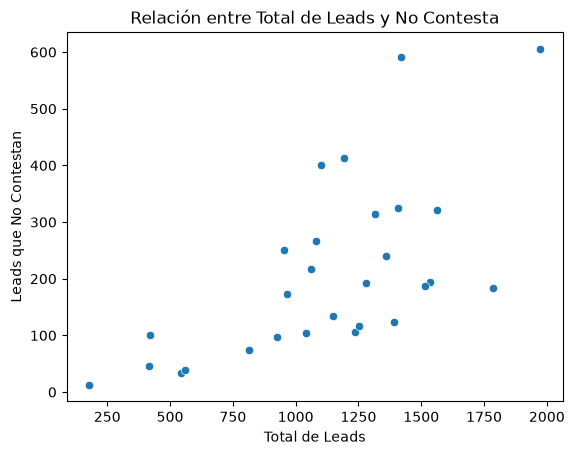

In [40]:
# Gráfica de dispersión Total vs No Contesta

sns.scatterplot(
    x='Total',
    y='No Contesta',
    data=df
)

plt.title('Relación entre Total de Leads y No Contesta')
plt.xlabel('Total de Leads')
plt.ylabel('Leads que No Contestan')

plt.show()

In [41]:
# Declaramos variable independiente y dependiente

Vars_Indep = df[['Total']]
Var_Dep = df['No Contesta']

In [42]:
# Modelo de regresión lineal

model_no_contesta = LinearRegression()

model_no_contesta.fit(
    X=Vars_Indep,
    y=Var_Dep
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.23]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Total']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-54.38
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [43]:
# Pendiente, intercepto y R²

print("Pendiente:", model_no_contesta.coef_[0])
print("Intercepto:", model_no_contesta.intercept_)
print(
    "R²:",
    model_no_contesta.score(Vars_Indep, Var_Dep)
)

Pendiente: 0.23493974256526987
Intercepto: -54.37519665186019
R²: 0.4157857762663172


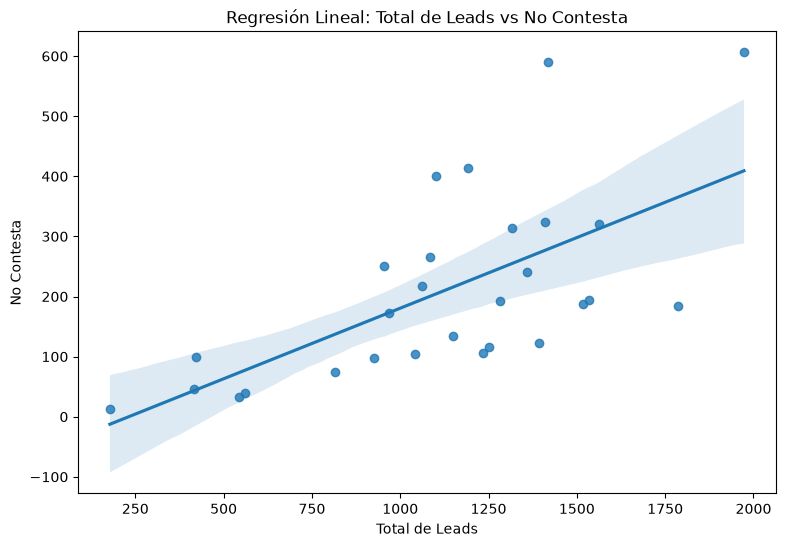

In [44]:
plt.figure(figsize=(9, 6))

sns.regplot(
    x='Total',
    y='No Contesta',
    data=df
)

plt.title('Regresión Lineal: Total de Leads vs No Contesta')
plt.xlabel('Total de Leads')
plt.ylabel('No Contesta')

plt.show()

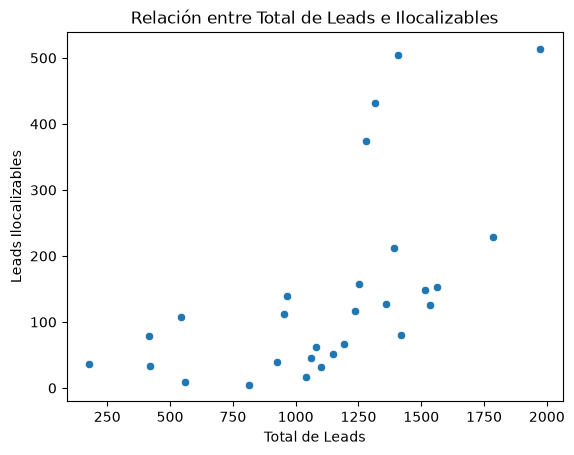

In [45]:
# Gráfica de dispersión Total vs Ilocalizable

sns.scatterplot(
    x='Total',
    y='Ilocalizable',
    data=df
)

plt.title('Relación entre Total de Leads e Ilocalizables')
plt.xlabel('Total de Leads')
plt.ylabel('Leads Ilocalizables')

plt.show()

In [46]:
# Variable independiente y dependiente

Vars_Indep = df[['Total']]
Var_Dep = df['Ilocalizable']

In [47]:
# Modelo de regresión lineal

model_ilocalizable = LinearRegression()

model_ilocalizable.fit(
    X=Vars_Indep,
    y=Var_Dep
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.2]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Total']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-81.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [48]:
print("Pendiente:", model_ilocalizable.coef_[0])
print("Intercepto:", model_ilocalizable.intercept_)
print("R²:", model_ilocalizable.score(Vars_Indep, Var_Dep))

Pendiente: 0.20029828553576687
Intercepto: -81.72778918730396
R²: 0.3458731920855532


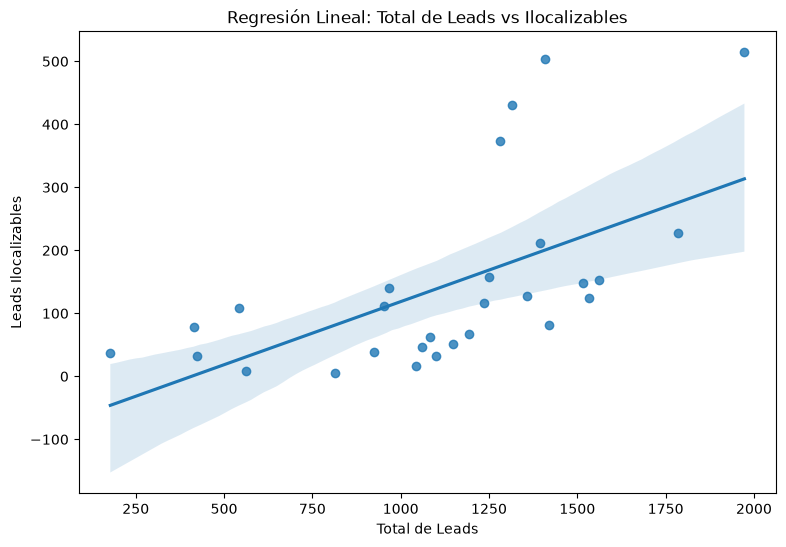

In [49]:
plt.figure(figsize=(9, 6))

sns.regplot(
    x='Total',
    y='Ilocalizable',
    data=df
)

plt.title('Regresión Lineal: Total de Leads vs Ilocalizables')
plt.xlabel('Total de Leads')
plt.ylabel('Leads Ilocalizables')

plt.show()

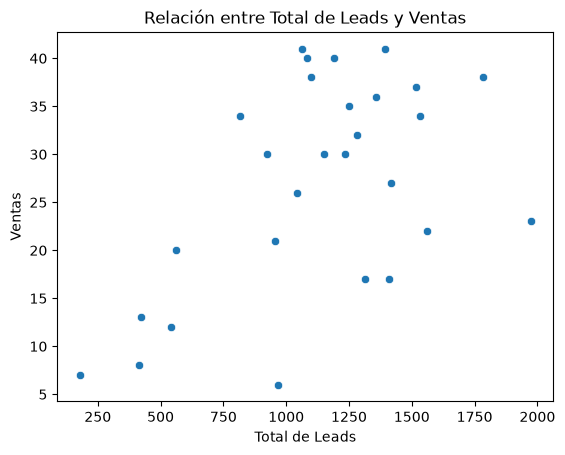

In [50]:
# Gráfica de dispersión Total vs Ventas

sns.scatterplot(
    x='Total',
    y='Ventas',
    data=df
)

plt.title('Relación entre Total de Leads y Ventas')
plt.xlabel('Total de Leads')
plt.ylabel('Ventas')

plt.show()

In [51]:
Vars_Indep = df[['Total']]
Var_Dep = df['Ventas']

model_ventas = LinearRegression()

model_ventas.fit(
    X=Vars_Indep,
    y=Var_Dep
)

print("Pendiente:", model_ventas.coef_[0])
print("Intercepto:", model_ventas.intercept_)
print("R²:", model_ventas.score(Vars_Indep, Var_Dep))

Pendiente: 0.014042286123493446
Intercepto: 11.19680443847736
R²: 0.2857589728587685


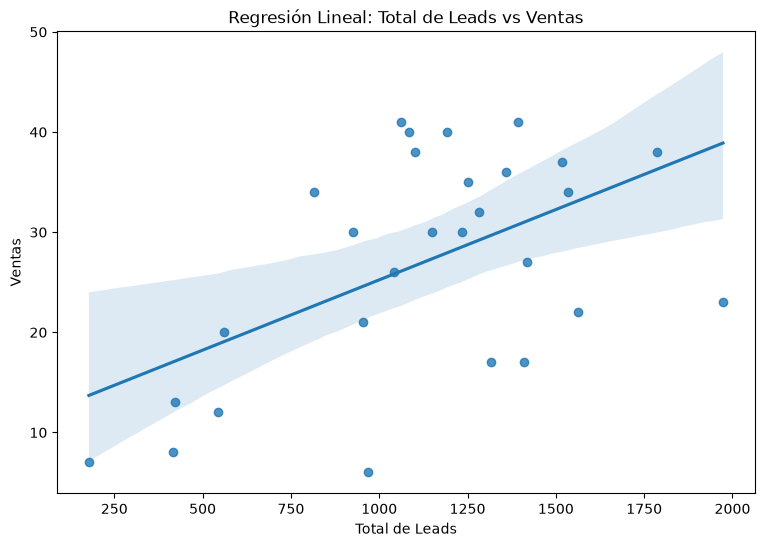

In [52]:
plt.figure(figsize=(9, 6))

sns.regplot(
    x='Total',
    y='Ventas',
    data=df
)

plt.title('Regresión Lineal: Total de Leads vs Ventas')
plt.xlabel('Total de Leads')
plt.ylabel('Ventas')

plt.show()

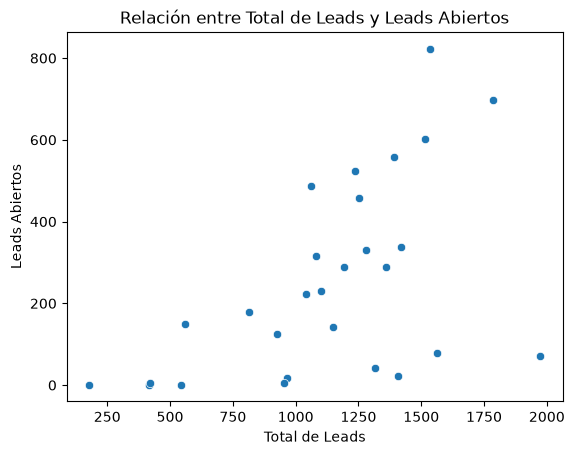

In [53]:
sns.scatterplot(
    x='Total',
    y='Abiertos',
    data=df
)

plt.title('Relación entre Total de Leads y Leads Abiertos')
plt.xlabel('Total de Leads')
plt.ylabel('Leads Abiertos')

plt.show()

In [54]:
Vars_Indep = df[['Total']]
Var_Dep = df['Abiertos']

model_abiertos = LinearRegression()

model_abiertos.fit(
    X=Vars_Indep,
    y=Var_Dep
)

print("Pendiente:", model_abiertos.coef_[0])
print("Intercepto:", model_abiertos.intercept_)
print("R²:", model_abiertos.score(Vars_Indep, Var_Dep))

Pendiente: 0.29560997680239137
Intercepto: -81.82063109525663
R²: 0.279187027616565


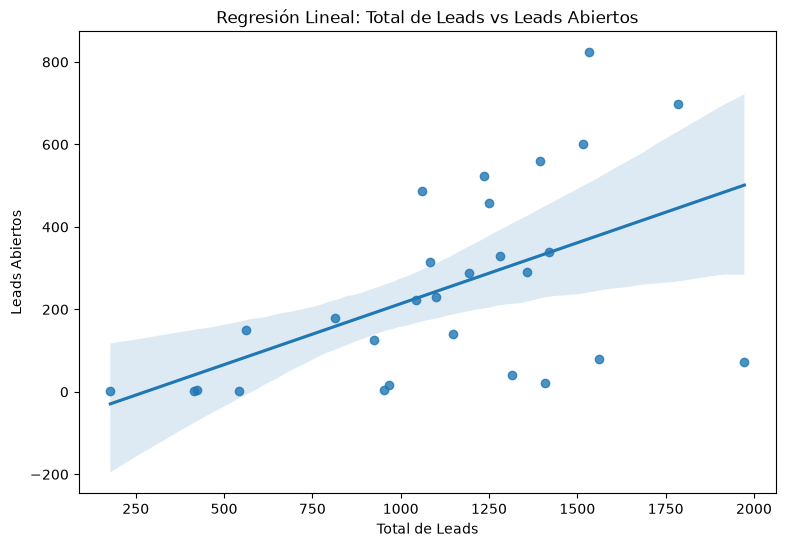

In [55]:
plt.figure(figsize=(9, 6))

sns.regplot(
    x='Total',
    y='Abiertos',
    data=df
)

plt.title('Regresión Lineal: Total de Leads vs Leads Abiertos')
plt.xlabel('Total de Leads')
plt.ylabel('Leads Abiertos')

plt.show()

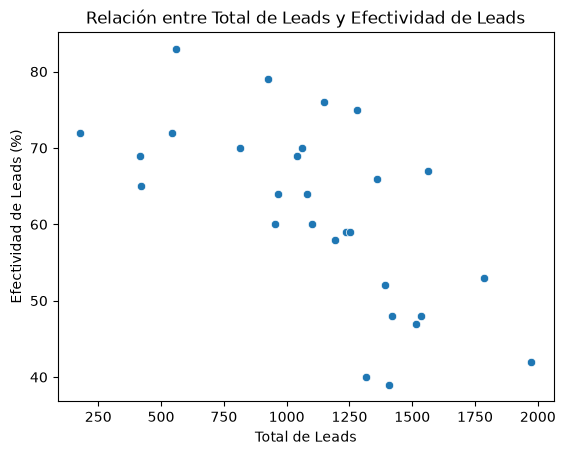

In [56]:
sns.scatterplot(
    x='Total',
    y='Efectividad de Leads',
    data=df
)

plt.title('Relación entre Total de Leads y Efectividad de Leads')
plt.xlabel('Total de Leads')
plt.ylabel('Efectividad de Leads (%)')

plt.show()

In [57]:
Vars_Indep = df[['Total']]
Var_Dep = df['Efectividad de Leads']

model_efectividad = LinearRegression()

model_efectividad.fit(
    X=Vars_Indep,
    y=Var_Dep
)

print("Pendiente:", model_efectividad.coef_[0])
print("Intercepto:", model_efectividad.intercept_)
print("R²:", model_efectividad.score(Vars_Indep, Var_Dep))

Pendiente: -0.018450443968990284
Intercepto: 82.36006994232338
R²: 0.4274232369675123


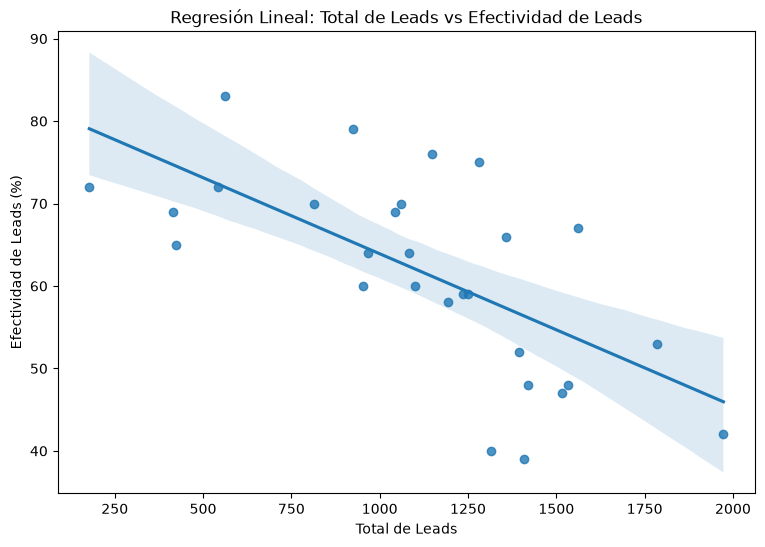

In [58]:
plt.figure(figsize=(9, 6))

sns.regplot(
    x='Total',
    y='Efectividad de Leads',
    data=df
)

plt.title('Regresión Lineal: Total de Leads vs Efectividad de Leads')
plt.xlabel('Total de Leads')
plt.ylabel('Efectividad de Leads (%)')

plt.show()

In [59]:
resultados = pd.DataFrame({
    'Relación': [
        'Total - Efectivos',
        'Total - No Contesta',
        'Total - Ilocalizable',
        'Total - Ventas',
        'Total - Abiertos',
        'Total - Efectividad de Leads'
    ],
    'Correlación': [
        0.812,
        0.645,
        0.588,
        0.535,
        0.528,
        -0.654
    ],
    'R²': [
        0.659,
        0.416,
        0.346,
        0.286,
        0.279,
        0.427
    ]
})

resultados

,Relación,Correlación,R²
0,Total - Efectivos,0.812,0.659
1,Total - No Contesta,0.645,0.416
2,Total - Ilocalizable,0.588,0.346
3,Total - Ventas,0.535,0.286
4,Total - Abiertos,0.528,0.279
5,Total - Efectividad de Leads,-0.654,0.427


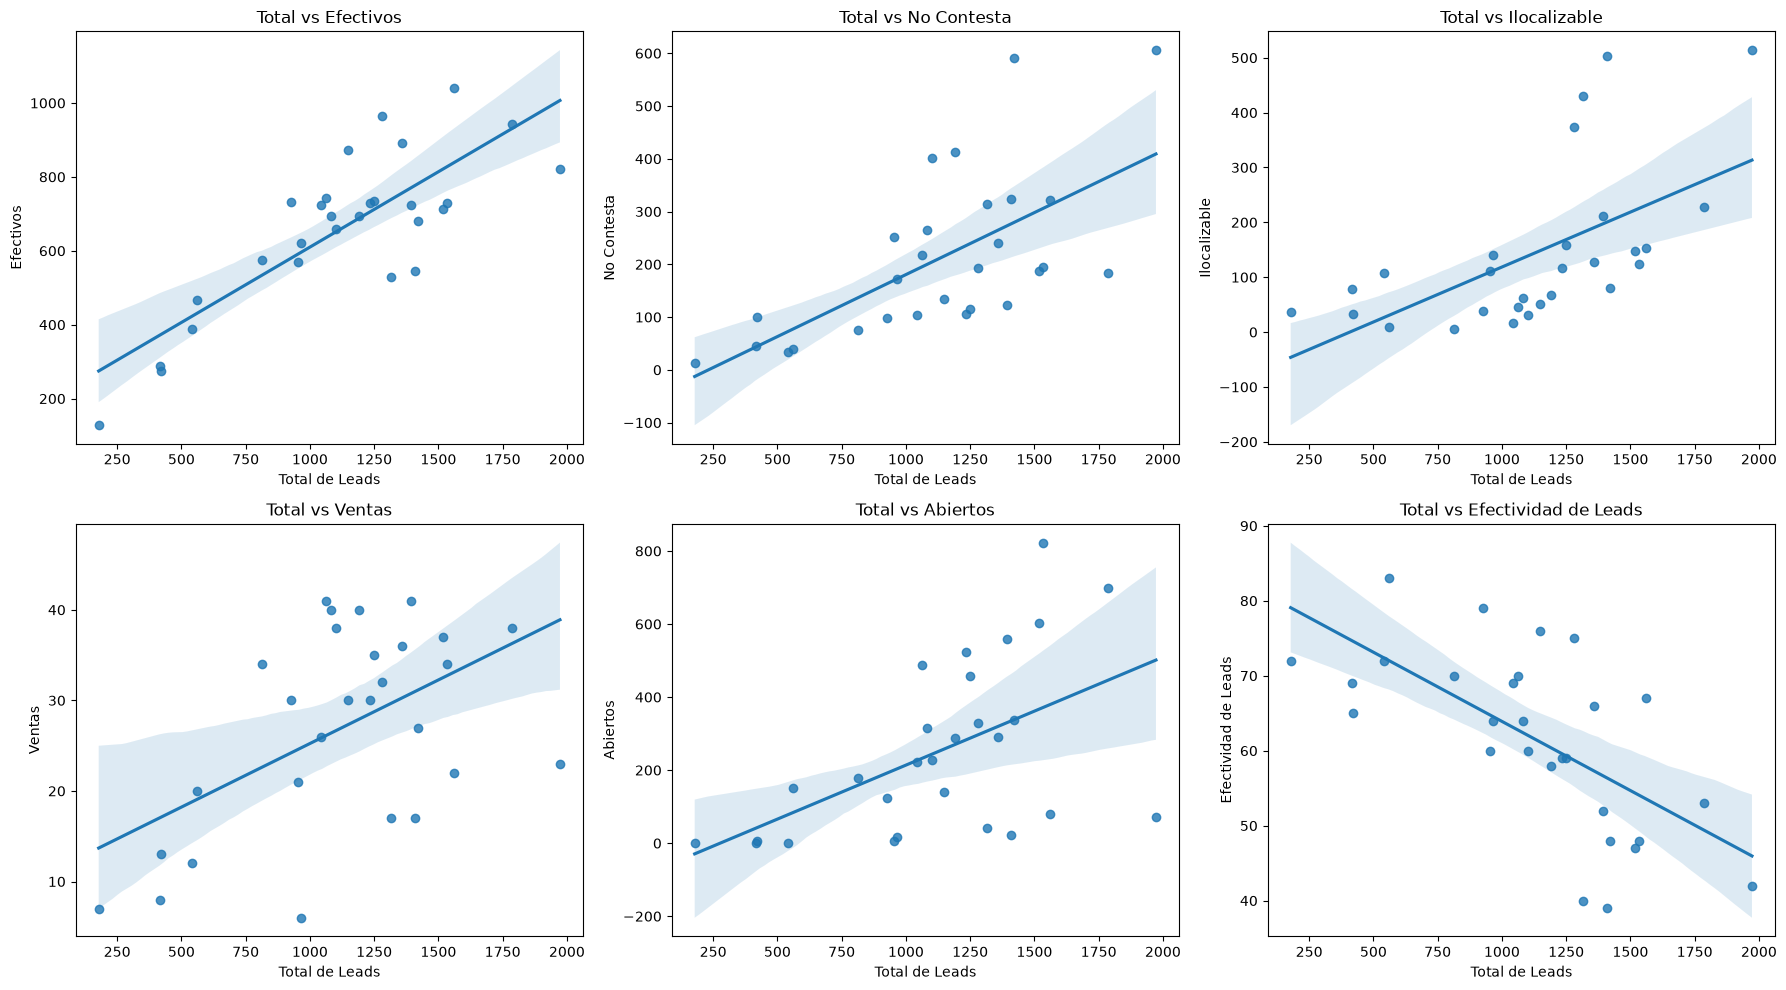

In [60]:
# Variables con mayor relación respecto al Total de Leads

variables_relacionadas = [
    'Efectivos',
    'No Contesta',
    'Ilocalizable',
    'Ventas',
    'Abiertos',
    'Efectividad de Leads'
]

# Creamos gráficas de correlación con línea de regresión

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, variable in enumerate(variables_relacionadas):

    sns.regplot(
        x='Total',
        y=variable,
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f'Total vs {variable}')
    axes[i].set_xlabel('Total de Leads')
    axes[i].set_ylabel(variable)

plt.tight_layout()
plt.show()

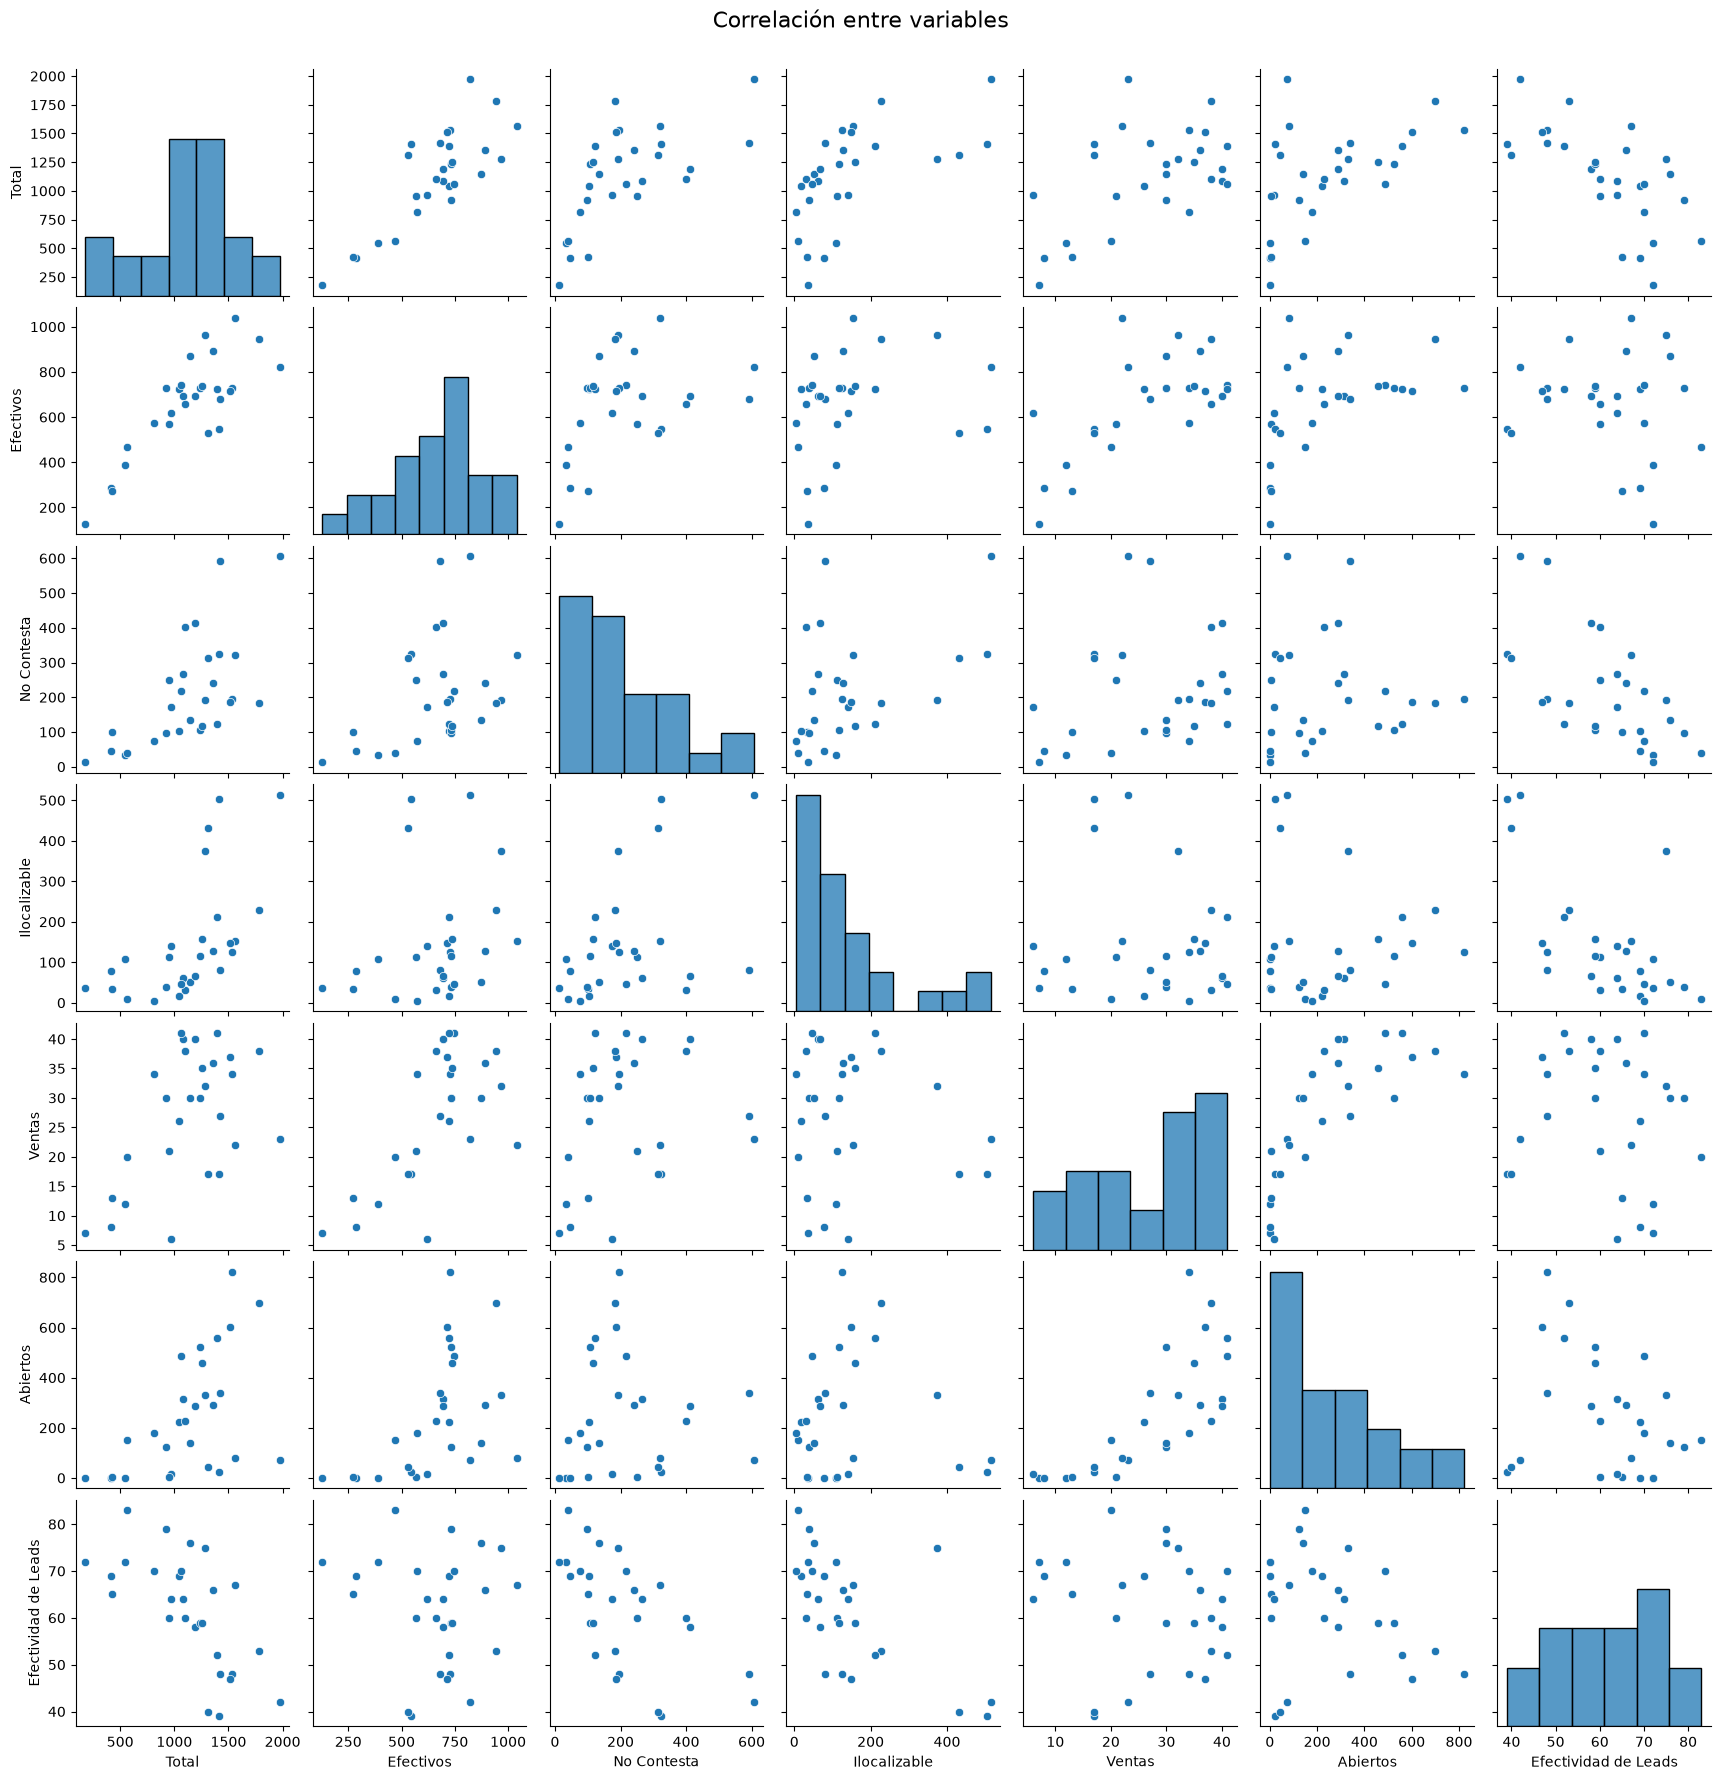

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_grafica = [
    'Total',
    'Efectivos',
    'No Contesta',
    'Ilocalizable',
    'Ventas',
    'Abiertos',
    'Efectividad de Leads'
]

sns.pairplot(
    df[variables_grafica],
    diag_kind='hist'
)

plt.suptitle('Correlación entre variables', y=1.02, fontsize=16)
plt.show()